# E-Commerce Product Delivery Prediction 

**Exploratory Data Analysis**

**Objective**
To explore and understand the dataset before building a predictive model for delivery delay.

**Target Variable**
Reached.on.Time_Y.N
(1 = Delayed, 0 = On-Time)

In [ ]:
# Import core libraries for data analysis and visualization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Load dataset from raw data folder

df = pd.read_csv("../data/raw/E_Commerce.csv")

# Display first 5 rows
df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


## Basic Data Overview

In [7]:
# Check data type and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


In [8]:
# stats summary
df.describe()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,5500.00000,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,3175.28214,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,1.00000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,2750.50000,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,5500.00000,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,8249.50000,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,10999.00000,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000


In [9]:
# Check missing values
df.isnull().sum()

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64

In [10]:
# checking duplicated rows
df.duplicated().sum()

np.int64(0)

In [11]:
# Check shape
df.shape

(10999, 12)

In [28]:
## PROJECT CONFIGURATION

# 1. Target & Split
TARGET_COL = "Reached.on.Time_Y.N"
TEST_SIZE = 0.2
RANDOM_STATE = 42
CV_FOLDS = 5

# 2. Model Evaluation
SCORING = "roc_auc"

# 3. Feature Groups
NUM_COLS = [
    'Cost_of_the_Product',
    'Weight_in_gms',
    'Discount_offered',
    'Customer_care_calls',
    'Customer_rating',
    'Prior_purchases'
]

CAT_COLS = [
    'Warehouse_block',
    'Mode_of_Shipment',
    'Gender'
]

ORD_COLS = ['Product_importance']

print("✅ Configuration Loaded Successfully")

✅ Configuration Loaded Successfully


In [ ]:

# Checking Unique Values (Cardinality)
df.nunique()

Warehouse_block           5
Mode_of_Shipment          3
Customer_care_calls       6
Customer_rating           5
Cost_of_the_Product     215
Prior_purchases           8
Product_importance        3
Gender                    2
Discount_offered         65
Weight_in_gms          4034
Reached.on.Time_Y.N       2
dtype: int64

## Target Variable Distribution

**Objective:**  
Understand class imbalance in the dataset.

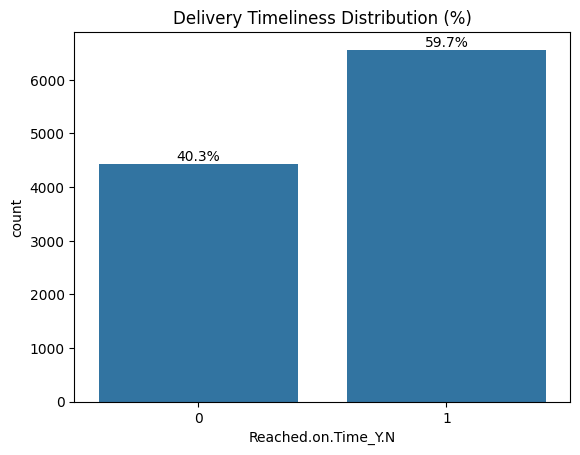

In [12]:
# Check class distribution visually
ax = sns.countplot(x="Reached.on.Time_Y.N", data=df)

total = len(df)

for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.title("Delivery Timeliness Distribution (%)")
plt.show()

# Numerical Feature Distributions

**Objective:**  
To understand the distribution, skewness, and spread of numerical variables.

**Why this is important:**  
- Detect skewness
- Identify possible outliers
- Decide if scaling or transformation is required

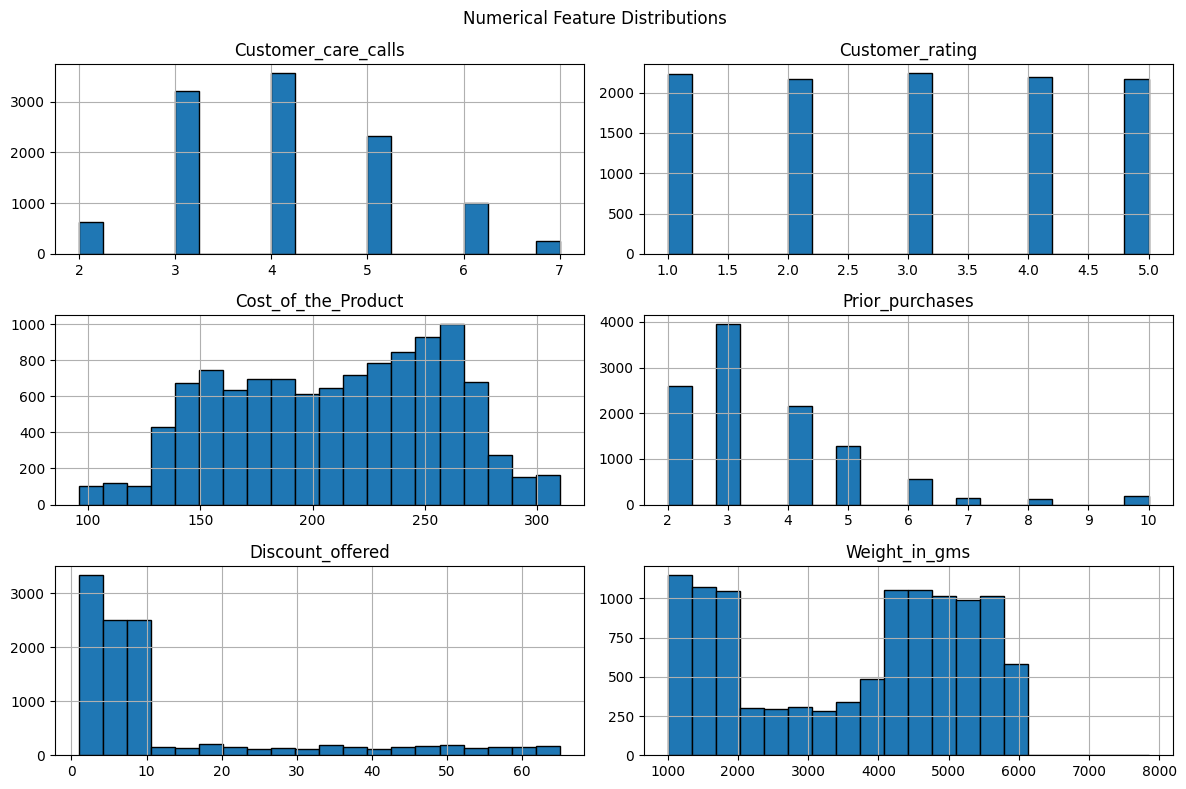

In [20]:
# Numerical Distribution Plot
num_cols = df.select_dtypes(include="int64").drop(columns=["ID", "Reached.on.Time_Y.N"]).columns

df[num_cols].hist(figsize=(12, 8), bins=20, edgecolor="black")
plt.suptitle("Numerical Feature Distributions")
plt.tight_layout()
plt.show()

**Observation:**
- Customer_care_calls and Customer_rating appear roughly uniform
- Cost_of_the_Product and Weight_in_gms are fairly normally distributed
- Discount_offered is heavily right-skewed — most orders have low discount, few have very high
- Prior_purchases is slightly right-skewed

**Conclusion:**
Discount_offered requires attention due to skewness — may need scaling before modeling.
No transformation is strictly required for other features, but standardization is recommended.

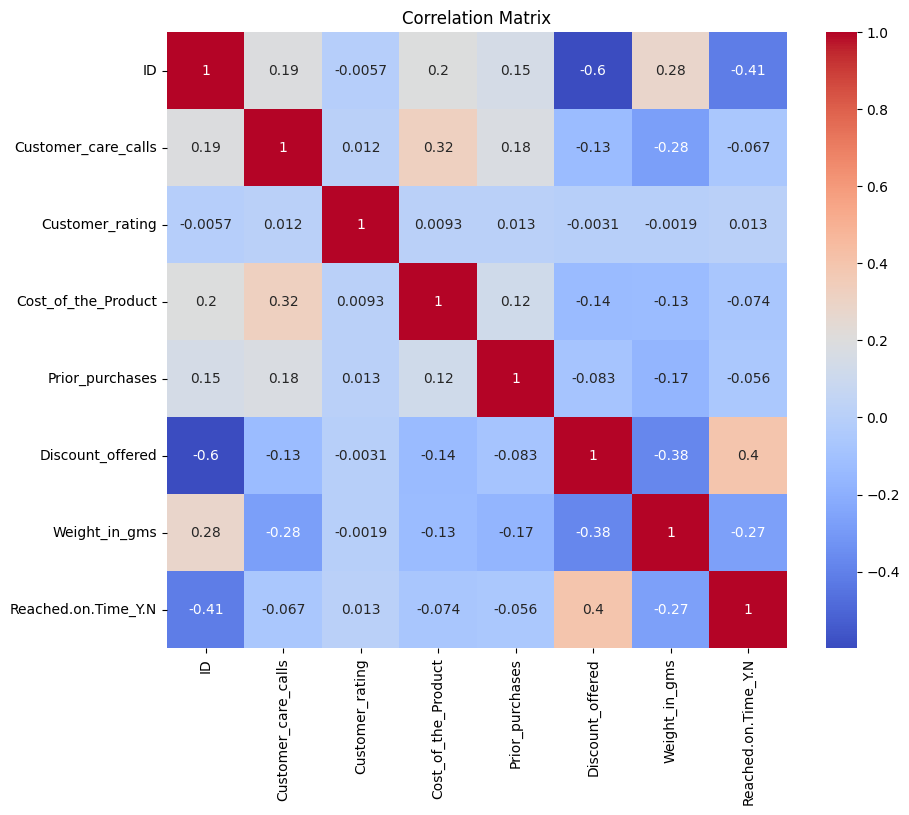

In [16]:
# Correlation matrix (numerical only)
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

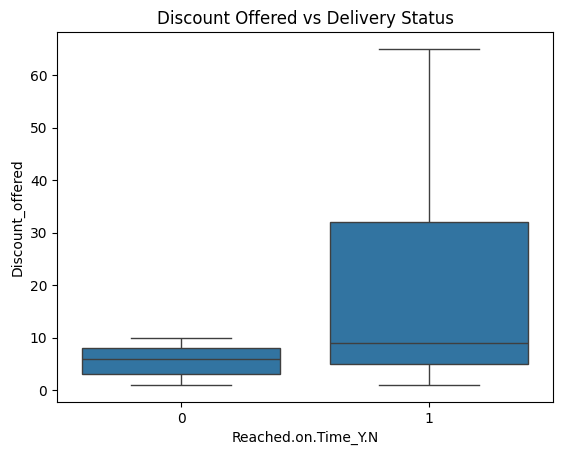

In [25]:
# Boxplot: Discount vs Delivery Status
sns.boxplot(x="Reached.on.Time_Y.N", y="Discount_offered", data=df)
plt.title("Discount Offered vs Delivery Status")
plt.show()

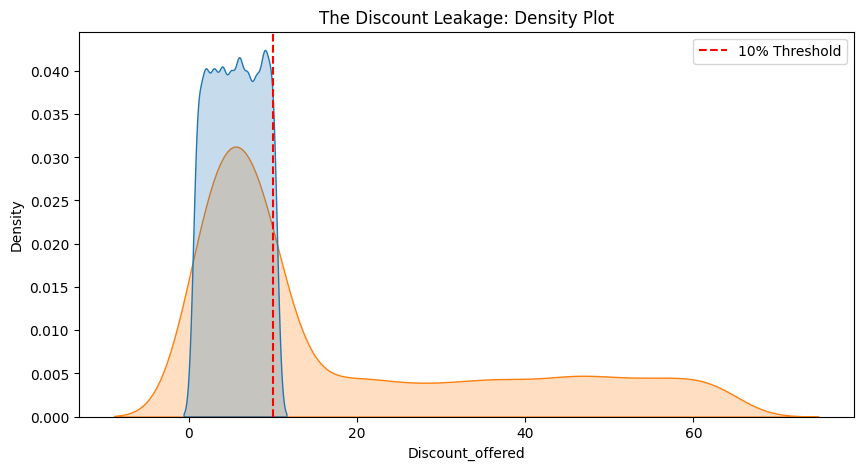

In [ ]:
# Use KDE plot to visualize the distribution overlap for Discount
plt.figure(figsize=(10,5))
sns.kdeplot(data=df, x="Discount_offered", hue="Reached.on.Time_Y.N", fill=True)
plt.axvline(10, color='red', linestyle='--', label='10% Threshold')
plt.title("The Discount Leakage: Density Plot")
plt.legend()
plt.show()

## Numerical Features vs Delivery Status

**Objective:**  
To compare the distribution of numerical variables between delayed and on-time deliveries.

**Why this is important:**  
- Identify separation between classes
- Detect strong predictive variables
- Validate correlation findings visually

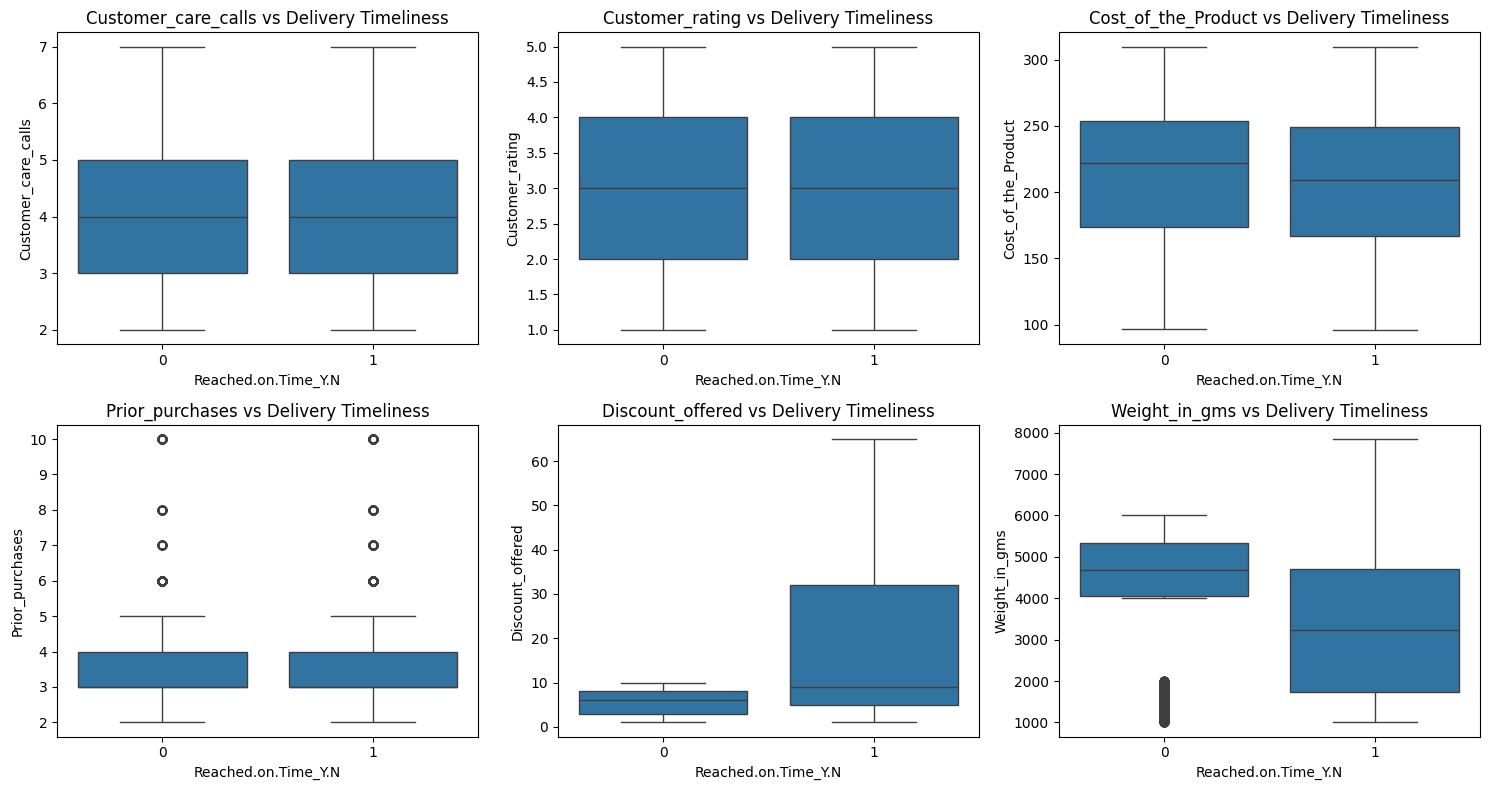

In [19]:
# Boxplots for ALL numerical features vs target
num_cols = ["Customer_care_calls", "Customer_rating", "Cost_of_the_Product",
            "Prior_purchases", "Discount_offered", "Weight_in_gms"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x="Reached.on.Time_Y.N", y=col, data=df, ax=axes[i])
    axes[i].set_title(f"{col} vs Delivery Timeliness")

plt.tight_layout()
plt.show()

**Observation:**
- Discount_offered shows clear separation between late and on-time deliveries.
- Weight_in_gms shows noticeable difference between classes.
- Other features show overlapping distributions.

**Conclusion:**
Discount_offered is the strongest numerical predictor.
Weight_in_gms may also contribute.
Remaining numerical variables have limited separation power.

## Categorical Features vs Delivery Status

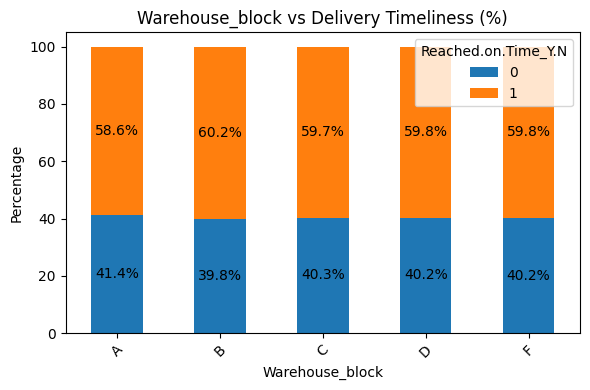

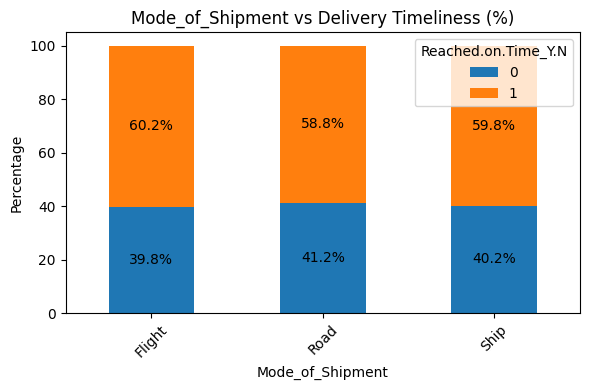

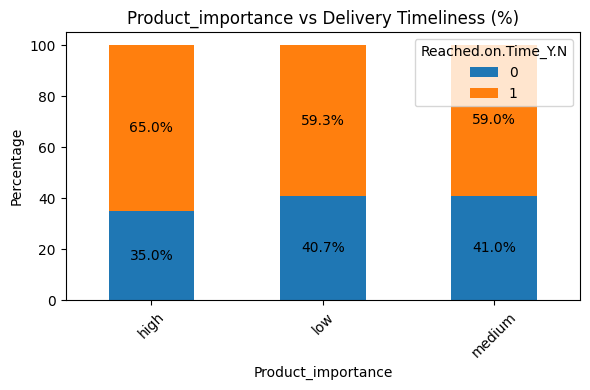

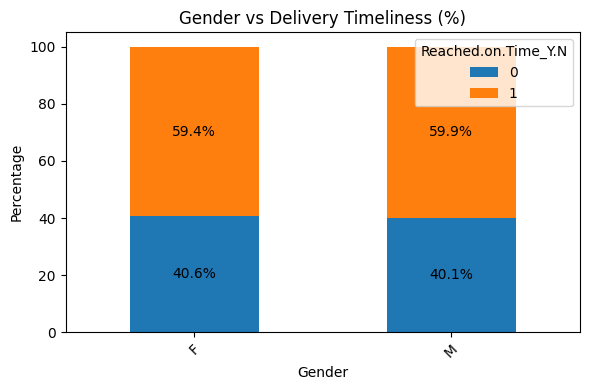

In [15]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    ct = pd.crosstab(df[col],
                     df["Reached.on.Time_Y.N"],
                     normalize="index") * 100
    
    ax = ct.plot(kind="bar",
                 stacked=True,
                 figsize=(6,4))
    
    for container in ax.containers:
        ax.bar_label(container,
                     fmt="%.1f%%",
                     label_type="center")
    
    plt.title(f"{col} vs Delivery Timeliness (%)")
    plt.ylabel("Percentage")
    plt.xticks(rotation=45)
    plt.legend(title="Reached.on.Time_Y.N")
    plt.tight_layout()
    plt.show()

## EDA Summary
**Class Distribution:**

The dataset is moderately imbalanced (~60% delayed deliveries).

**Strong Predictors:**

- Discount_offered shows strong positive relationship with delay.

- Weight_in_gms shows moderate negative relationship.

**Moderate/Weak Predictors:**

- Customer_care_calls and Prior_purchases show minor influence.

- Customer_rating and Cost_of_the_Product have weak separation.

**Categorical Variables:**
Most categorical features show minimal variation in delay percentage.
They may contribute less predictive power.

**Overall Conclusion:**
Numerical variables, especially Discount_offered and Weight_in_gms, are likely to play a major role in prediction.

## Business Insight

High discounts may lead to increased logistics pressure,
resulting in delayed deliveries.

This insight could help optimize promotional strategies.

In [22]:
# Drop ID column (not useful for modeling)
df = df.drop(columns=["ID"])

print("Columns after dropping ID:")
print(df.columns)

Columns after dropping ID:
Index(['Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')


In [24]:
import os

os.makedirs("../data/processed", exist_ok=True)

df.to_csv("../data/processed/cleaned_data.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


# Data Preprocessing

In [30]:
# Import Preprocessing Libraries

from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer

In [31]:
# Define Features and Target Variable

X = df.drop(TARGET_COL, axis=1)
y = df[TARGET_COL]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (10999, 10)
Target shape: (10999,)


In [32]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y        # Stratify to maintain class distribution in train and test sets
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (8799, 10)
Test Shape: (2200, 10)


# Observation: Successful Stratification

- Data Integrity: The training set (8,799 samples) and test set (2,200 samples) correctly represent the 80/20 split of the original 10,999 records.

- Class Balance: The target distribution is nearly identical in both sets (~59.6% Delayed, ~40.3% On-Time). This confirms that stratify=y worked perfectly, ensuring our model is evaluated on a representative sample of reality.

In [33]:
# Check target distribution in train and test sets
print("Train Target Distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest Target Distribution:")
print(y_test.value_counts(normalize=True))

Train Target Distribution:
Reached.on.Time_Y.N
1    0.596659
0    0.403341
Name: proportion, dtype: float64

Test Target Distribution:
Reached.on.Time_Y.N
1    0.596818
0    0.403182
Name: proportion, dtype: float64


In [34]:
# Preprocessing Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer

ordinal_encoder = OrdinalEncoder(categories=[['low', 'medium', 'high']])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), NUM_COLS),
        ('cat', OneHotEncoder(handle_unknown='ignore'), CAT_COLS),
        ('ord', ordinal_encoder, ORD_COLS)
    ]
)

In [35]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [36]:
# Define Models
models = {
    "Logistic Regression": LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier()
}

# Model Training
To identify the most suitable algorithm for predicting product delivery timeliness, multiple classification models were evaluated:

- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors

Each model was integrated into a preprocessing pipeline to ensure consistent feature transformation and to prevent data leakage.

Five-fold cross-validation was performed using ROC-AUC as the primary evaluation metric due to moderate class imbalance in the dataset.

In [ ]:
# Model Comparison
from sklearn.model_selection import cross_val_score

model_scores = {}

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('classifier', model)
    ])
    
    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=CV_FOLDS,
        scoring=SCORING
    )
    
    model_scores[name] = scores.mean()
    print(f"{name} CV ROC-AUC: {scores.mean():.4f}")

Logistic Regression CV ROC-AUC: 0.7177
Decision Tree CV ROC-AUC: 0.7378
Random Forest CV ROC-AUC: 0.7364
KNN CV ROC-AUC: 0.7139


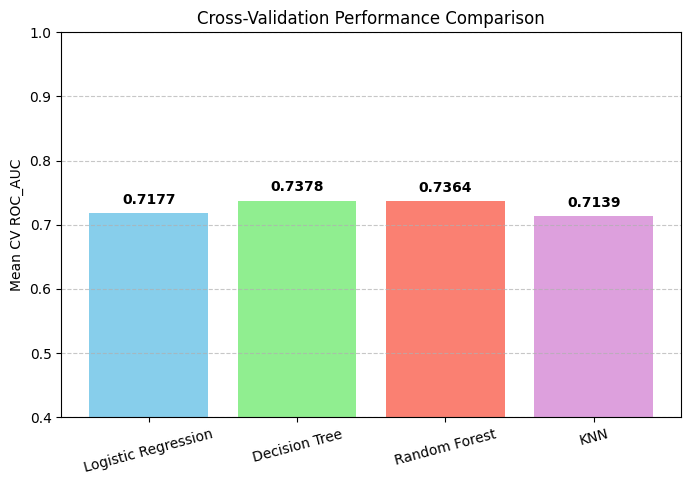

In [38]:
# Visualize Model Performance
import matplotlib.pyplot as plt
import seaborn as sns 
plt.figure(figsize=(8, 5))
# Create the bars
bars = plt.bar(model_scores.keys(), model_scores.values(), color=['skyblue', 'lightgreen', 'salmon', 'plum'])

# Add the exact numbers on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.4f}", ha='center', va='bottom', fontweight='bold')

plt.xticks(rotation=15)      # Less rotation is usually easier to read
plt.ylim(0.4, 1.0)         # Zoom in on the relevant ROC-AUC range
plt.ylabel(f"Mean CV {SCORING.upper()}")
plt.title("Cross-Validation Performance Comparison")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Observation: Tree-Based Superiority

- Model Performance: Both Decision Tree (0.7378) and Random Forest (0.7364) outperformed Logistic Regression and KNN.

- Insight: The success of the tree-based models suggests that the relationship between features (like Weight_in_gms and Discount_offered) and delivery delays is non-linear.

- Decision: While Decision Tree has the highest raw score, Random Forest is a strong candidate for final selection due to its ensemble nature, which typically offers better generalization on unseen data. However, for this baseline, we will proceed with the Decision Tree as the primary model.

In [39]:
# Select Best Model Based on CV ROC-AUC

best_model_name = max(model_scores, key=model_scores.get)
print("Best Model from Cross-Validation:", best_model_name)
print("Best CV ROC-AUC:", model_scores[best_model_name])

Best Model from Cross-Validation: Decision Tree
Best CV ROC-AUC: 0.7377740576037326


In [40]:
# Build Final Model Pipeline

final_model = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', models[best_model_name])
])

In [41]:
# Train Final Model on Training Data

final_model.fit(X_train, y_train)

print("Final model trained successfully.")

Final model trained successfully.


In [42]:
# Test Set Predictions

y_pred = final_model.predict(X_test)

# For ROC-AUC we need probabilities
y_prob = final_model.predict_proba(X_test)[:, 1]

In [43]:
# Performance Evaluation

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nROC-AUC:", roc_auc)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(cm)

Accuracy: 0.6795454545454546

ROC-AUC: 0.736474900633763

Classification Report:

              precision    recall  f1-score   support

           0       0.56      0.98      0.71       887
           1       0.97      0.48      0.64      1313

    accuracy                           0.68      2200
   macro avg       0.76      0.73      0.68      2200
weighted avg       0.80      0.68      0.67      2200


Confusion Matrix:

[[867  20]
 [685 628]]


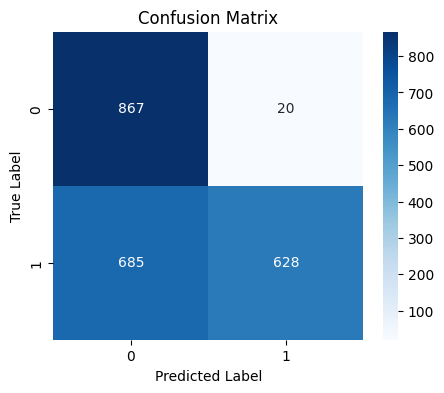

In [ ]:
# Visualize Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Observation: Precision-Focused Baseline

- Low False Alarm Rate: The model is exceptionally "cautious." With only 20 False Positives, it has a Precision of ~97%. This means when the model says a package is late, it is almost certainly right.

- The Recall Gap: However, it misses roughly half of the actual delays (685 False Negatives). This indicates that at a 50% threshold, the model only flags the "most obvious" delays.

- Business Impact: This default setting is ideal for a "High-Confidence Alert System" where the company only wants to notify customers when a delay is nearly guaranteed.

# Threshold Analysis

- To explore the trade-off between precision and recall, the classification threshold was adjusted. Lowering the threshold significantly increased recall but resulted in a sharp decline in precision.

- This analysis highlights the importance of selecting a decision threshold based on business objectives. If minimizing missed delays is critical, a lower threshold may be preferred. However, excessive false positives could lead to operational inefficiencies.

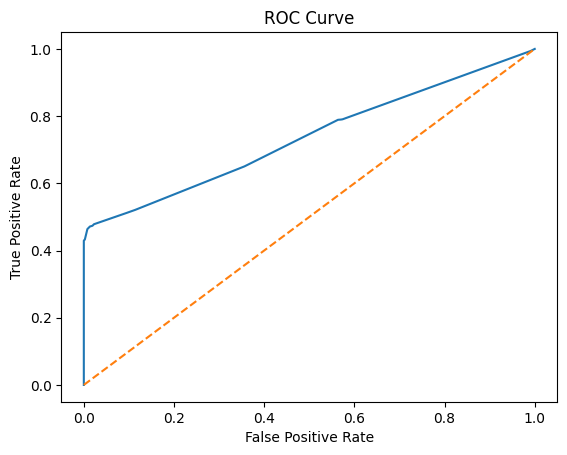

In [ ]:
# ROC-AUC used as primary metric because dataset is moderately imbalanced
# ROC Curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [ ]:
# Threshold adjusted to analyze precision-recall trade-off for business cost evaluation
# Try lower threshold
custom_threshold = 0.35
y_pred_custom = (y_prob >= custom_threshold).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.50      0.01      0.02       887
           1       0.60      0.99      0.75      1313

    accuracy                           0.60      2200
   macro avg       0.55      0.50      0.38      2200
weighted avg       0.56      0.60      0.45      2200



# An analytical insight after threshold tunning: 
- To analyze the precision-recall trade-off, the classification threshold was adjusted.

- Lowering the threshold significantly increased recall but resulted in reduced precision and overall accuracy.

- This demonstrates that threshold selection should be aligned with business objectives, particularly when considering the operational cost of false positives versus false negatives.

In [48]:
# Feature Importance Analysis (for tree-based models)
# Extract trained Decision Tree
dt_model = final_model.named_steps['classifier']

# Get feature names after preprocessing
ohe = final_model.named_steps['preprocessing'].named_transformers_['cat']
encoded_cat_cols = ohe.get_feature_names_out(CAT_COLS)

all_features = NUM_COLS + list(encoded_cat_cols) + ORD_COLS

importances = dt_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": all_features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance_df.head(10)

,Feature,Importance
2,Discount_offered,0.803732
1,Weight_in_gms,0.095667
5,Prior_purchases,0.077804
0,Cost_of_the_Product,0.018363
4,Customer_rating,0.004435
3,Customer_care_calls,0.000000
6,Warehouse_block_A,0.000000
7,Warehouse_block_B,0.000000
8,Warehouse_block_C,0.000000
9,Warehouse_block_D,0.000000


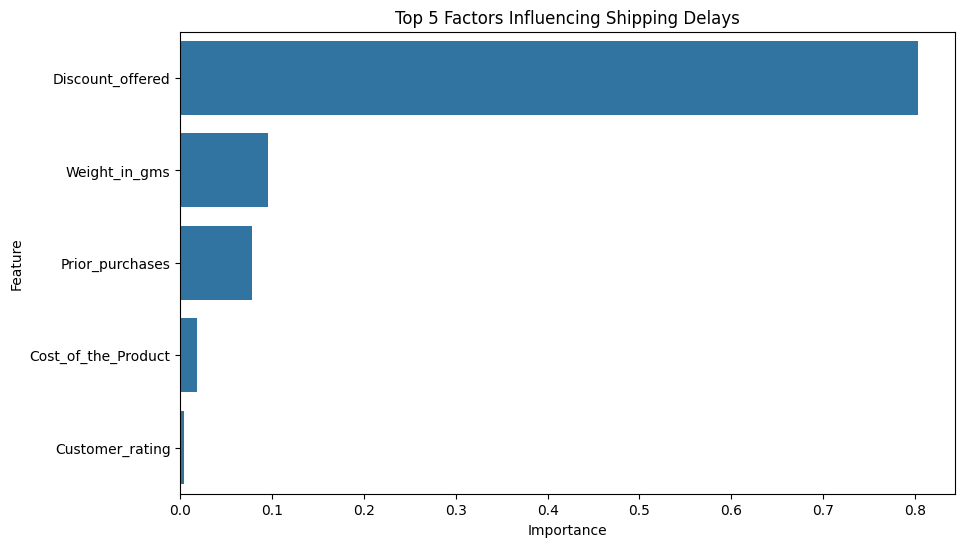

In [49]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(5))
plt.title('Top 5 Factors Influencing Shipping Delays')
plt.show()

# Feature Importance Analysis

- Feature importance analysis revealed that `Discount_offered` contributes approximately 80% of the model’s predictive power. This indicates a strong relationship between discount strategy and delivery delays.

- Other features such as product weight and prior purchases contribute moderately, while remaining variables show minimal impact.

- This suggests that promotional strategies may significantly influence logistical performance and should be aligned with operational capacity planning.

# Conclusion:
- This project successfully developed and evaluated multiple machine learning models to predict product delivery timeliness.

- Among the evaluated models, the Decision Tree classifier achieved the best cross-validation performance.

- The analysis indicates that discount strategy plays a dominant role in delivery delays, providing valuable operational insights for logistics planning and customer satisfaction improvement.

- Further enhancement could be achieved by incorporating additional operational features such as delivery distance, traffic data, and seasonal demand indicators.